<img src="https://devra.ai/analyst/notebook/4114/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">    <div style="font-size:150%; color:#FEE100"><b>Salary Prediction Analysis Notebook</b></div>    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

## Table of Contents

- [Introduction](#Introduction)
- [Data Loading](#Data-Loading)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Model Training and Evaluation](#Model-Training-and-Evaluation)
- [Discussion and Future Work](#Discussion-and-Future-Work)

# Introduction

A curious fact about the salary data: even a straightforward dataset can offer a lot of insight if you look at it with a mix of humor and a dash of skepticism. In this notebook, we explore the relationship between years of experience and salary, and even predict salary based on experience using a linear regression model. If you find this analysis insightful, please consider upvoting it.

In [1]:
# Import necessary libraries and setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is imported

import seaborn as sns

# Scikit-learn modules for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

%matplotlib inline

# Setting aesthetic parameters for seaborn
sns.set_style('whitegrid')

# Note: Each cell is carefully commented. If you encounter issues with matplotlib, make sure the correct backend is set.

# Data Loading

We load the salary prediction dataset which is stored in a CSV file. This dataset comprises two columns: YearsExperience and Salary.

In [2]:
# Define the file path and load the dataset
file_path = '/kaggle/input/salary-prediction-dataset/Salary_Data.csv'
df = pd.read_csv(file_path, encoding='ascii', delimiter=',')

# Display the first few rows of the dataset
print('Dataset shape:', df.shape)
print(df.head())

Dataset shape: (30, 2)
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


# Data Cleaning and Preprocessing

In this section, we check for null or missing values and ensure that the data types are as expected. Although this dataset is simple, verifying the data improves reliability of subsequent analysis.

In [3]:
# Check for missing values in the dataset
print('Missing values in each column:')
print(df.isnull().sum())

# Check the data types of each column
print('\nData types:')
print(df.dtypes)

# Since the data does not include a date column, we proceed without any date-type inference.

# It is important to perform these checks to avoid issues during model training and analysis.

Missing values in each column:
YearsExperience    0
Salary             0
dtype: int64

Data types:
YearsExperience    float64
Salary             float64
dtype: object


# Exploratory Data Analysis

This section explores the nature of our salary data using various visualizations. We include histograms, scatter plots, and pair plots to examine the distribution and relationships between the features.

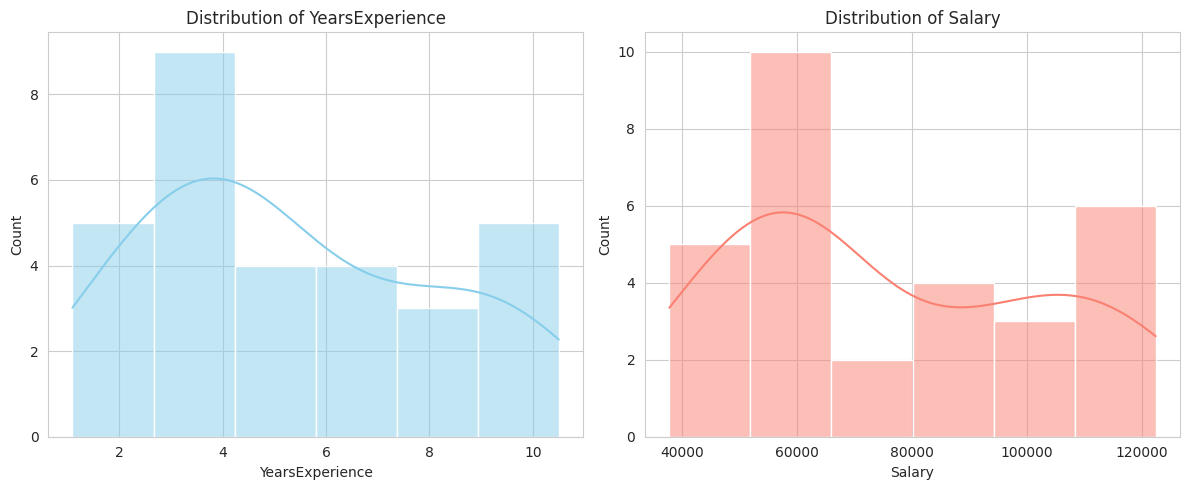

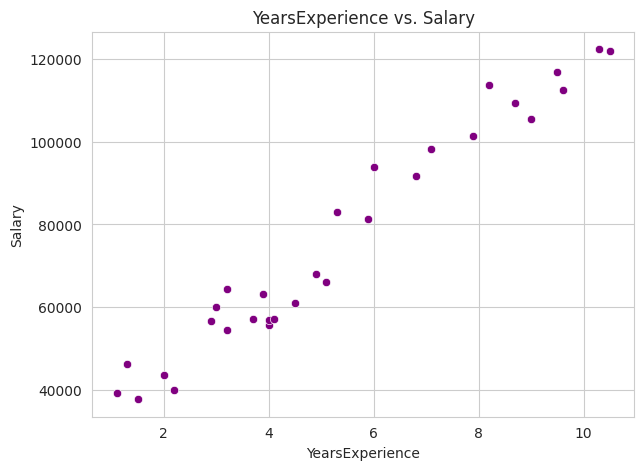

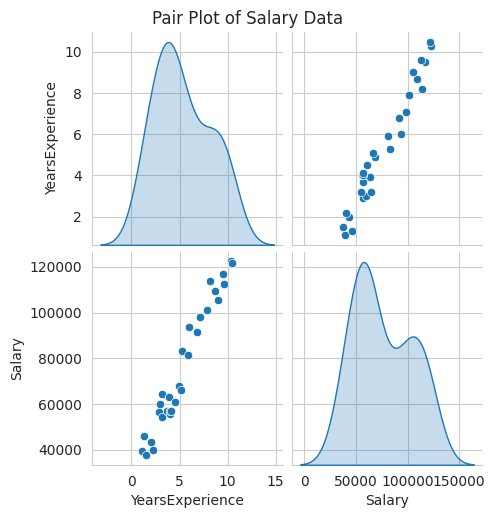

Skipping correlation heatmap: requires 4 or more numeric columns.


In [4]:
# Histogram of YearsExperience and Salary
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['YearsExperience'], kde=True, color='skyblue')
plt.title('Distribution of YearsExperience')

plt.subplot(1, 2, 2)
sns.histplot(df['Salary'], kde=True, color='salmon')
plt.title('Distribution of Salary')

plt.tight_layout()
plt.show()

# Scatter plot to visualize the relationship between YearsExperience and Salary
plt.figure(figsize=(7, 5))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, color='purple')
plt.title('YearsExperience vs. Salary')
plt.show()

# Pair plot for overall relationship visualization
sns.pairplot(df, kind='scatter', diag_kind='kde')
plt.suptitle('Pair Plot of Salary Data', y=1.02)
plt.show()

# For correlation analysis, we would normally reduce the dataframe to numeric columns.
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print('Skipping correlation heatmap: requires 4 or more numeric columns.')

# This explorer section is crucial, even if simple, since insights here can drive the modeling decisions.

# Model Training and Evaluation

We build a linear regression model to predict Salary based on YearsExperience. The dataset is split into training and testing sets to evaluate the performance of the predictor. We use R-squared as the evaluation metric, and also compute permutation importance to assess the impact of the feature.

Training R-squared: 0.9645401573418146
Testing R-squared: 0.9024461774180497


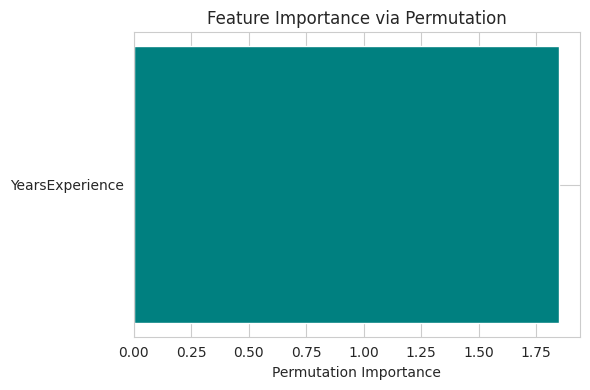

In [5]:
# Prepare the data for modeling
X = df[['YearsExperience']].values  # Predictor: YearsExperience
y = df['Salary'].values             # Response: Salary

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate the model using R-squared metric
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Training R-squared:', train_r2)
print('Testing R-squared:', test_r2)

# Permutation importance to assess feature impact
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
feature_names = ['YearsExperience']

# Plot permutation importance
plt.figure(figsize=(6, 4))
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(np.array(feature_names)[sorted_idx], perm_importance.importances_mean[sorted_idx], color='teal')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance via Permutation')
plt.tight_layout()
plt.show()

# Note: While the model is extremely simple due to a single predictor, these methods are scalable for more complex datasets.

# Discussion and Future Work

The linear regression model demonstrates how even a basic predictor can achieve respectable R-squared values. Although the dataset here is simple and limited to one predictor, we have demonstrated the following approaches:

- Data loading and preprocessing with checks for missing values and data types.
- Various exploratory data analysis techniques such as histograms, scatter plots, and pair plots.
- Model training with a linear regression and evaluation using R-squared.
- Feature impact analysis using permutation importance.

For future analysis, one could explore more advanced models, gather more features, or even apply cross-validation to further validate the model's performance. If you find these techniques and insights useful, please consider upvoting.